<a href="https://colab.research.google.com/github/aretiz/DAMSL-373/blob/main/tutorial_VAEs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implementing basic Variational Autoencoders (VAEs)**


**Lets Generate Some Numbers** 🔢

# Variational Autoencoders (VAEs)
![](https://raw.githubusercontent.com/mikerapt/hy673_tutorials/98337f6cf32c62980ec3c8059dfbcef61faffbc5/Tutorial-8/fig/vae.png)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np

import torch
import torch.nn.functional as F
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

import os
from tqdm import tqdm

import numpy as np
import torch
import matplotlib.pyplot as plt

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#Load the MNIST dataset!

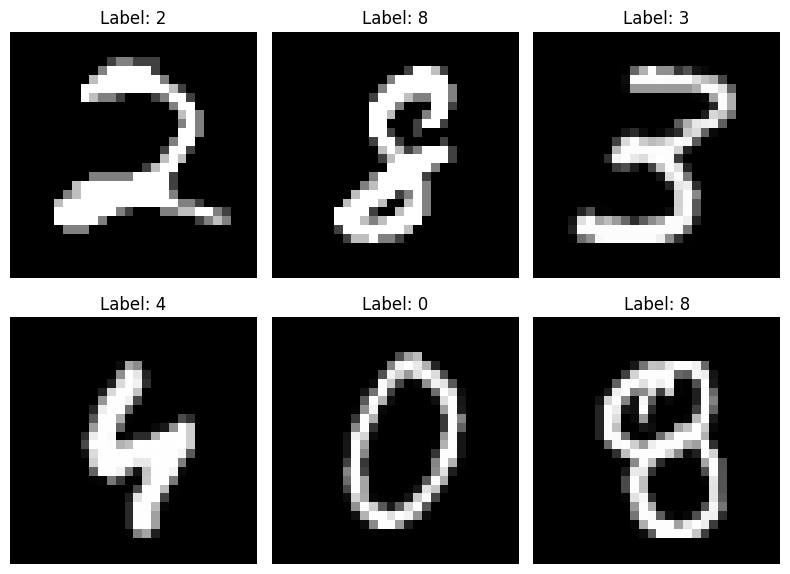

In [ ]:
batch_size = 128

train_dataset = MNIST(root='./data', train=True, transform=ToTensor(), download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


# Get a batch of images to visualize
data_iter = iter(train_loader)
images, labels = next(data_iter)  # Get first batch

# Plot the first 6 images
fig, axes = plt.subplots(2, 3, figsize=(8, 6))
axes = axes.flatten()

for i in range(6):
    img = images[i].squeeze(0)  # Remove the channel dimension
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


# Encoder and Decoder with Linear Layers

In [ ]:
class LinearEncoder(nn.Module):
    def __init__(self, input_dim:int, latent_dim:int=32):
        super(LinearEncoder, self).__init__()

        self.input_dim = input_dim
        self.latent_dim = latent_dim

        self.fc1 = nn.Linear(input_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, latent_dim * 2)

    def forward(self, x):
        x = x.view(-1, self.input_dim)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # no activation for the last layer

        # half of the latent values are used for the mean, half for the log-variance
        mu = x[:, :self.latent_dim]
        logvar = x[:, self.latent_dim:]
        return mu, logvar

class LinearDecoder(nn.Module):
    def __init__(self, input_dim:int, latent_dim:int=32):
        super(LinearDecoder, self).__init__()

        self.input_dim = input_dim
        self.latent_dim = latent_dim

        self.rev_fc3 = nn.Linear(self.latent_dim, 256)
        self.rev_fc2 = nn.Linear(256, 512)
        self.rev_fc1 = nn.Linear(512, self.input_dim)

    def forward(self, z):
        x = torch.relu(self.rev_fc3(z))
        x = torch.relu(self.rev_fc2(x))
        x = torch.sigmoid(self.rev_fc1(x))
        return x


# Encoder and Decoder with Convolutional Layers

In [ ]:
class ConvEncoder(nn.Module):

    def __init__(self, input_shape:tuple=(1, 28, 28), latent_dim:int=32):
        super(ConvEncoder, self).__init__()

        self.input_shape = input_shape
        self.latent_dim = latent_dim

        self.conv1 = nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1)

        # determine the output shapes for conv layers
        self.outconv1_shape = conv2Doutshape(self.input_shape, 16, kernel_size=4, stride=2, padding=1)
        self.outconv2_shape = conv2Doutshape(self.outconv1_shape, 32, kernel_size=4, stride=2, padding=1)

        # linear layers
        self.outconv_dim = np.prod(self.outconv2_shape)
        self.fc = nn.Linear(self.outconv_dim, 2*self.latent_dim)


    def forward(self, x):

        # x = x.view(-1, self.input_shape[0], self.input_shape[1], self.input_shape[2])
        x = x.view(-1, *self.input_shape)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))

        # flatten
        x = x.view(-1, self.outconv_dim)
        x = self.fc(x)

        mu = x[:, :self.latent_dim]
        logvar = x[:, self.latent_dim:]

        return mu, logvar


class ConvDecoder(nn.Module):

    def __init__(self, input_shape:tuple=(1, 28, 28), latent_dim:int=32):
        super(ConvDecoder, self).__init__()

        self.input_shape = input_shape
        self.latent_dim = latent_dim

        # determine the output shapes for conv layers
        self.outconv1_shape = conv2Doutshape(self.input_shape, 16, kernel_size=4, stride=2, padding=1)
        self.outconv2_shape = conv2Doutshape(self.outconv1_shape, 32, kernel_size=4, stride=2, padding=1)

        # define convtranspose layers
        self.convt2 = nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1)
        self.convt1 = nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1)

        # linear layers
        self.outconv_dim = np.prod(self.outconv2_shape)
        self.rev_fc = nn.Linear(self.latent_dim, self.outconv_dim)

    def forward(self, z):

        x = torch.relu(self.rev_fc(z))  # 32*7*7
        x = x.view(-1, *self.outconv2_shape)  # (32, 7, 7)
        x = torch.relu(self.convt2(x))  # (16, 14, 14)
        x = torch.sigmoid(self.convt1(x))  # (1, 28, 28)
        return x


"""
Get the output_shape of a Conv2D layer given the input_shape and parameters.
"""
def conv2Doutshape(input_shape:tuple, filters, kernel_size, stride=1, padding=0, dilation=1):

    if isinstance(kernel_size, (float, int)):
        kernel_size = (kernel_size, kernel_size)
    if isinstance(stride, (float, int)):
        stride = (stride, stride)
    if isinstance(padding, (float, int)):
        padding = (padding, padding)
    if isinstance(dilation, (float, int)):
        dilation = (dilation, dilation)

    _, h_in, w_in = input_shape

    # formula from https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
    c_out = filters
    h_out = int( (h_in + 2*padding[0] - dilation[0]*(kernel_size[0] - 1) -1)/stride[0] + 1)
    w_out = int( (w_in + 2*padding[1] - dilation[1]*(kernel_size[1] - 1) -1)/stride[1] + 1)

    return c_out, h_out, w_out

# VAE with linear or convolutional layers

In [ ]:
class VAE(nn.Module):

    def __init__(self, input_shape:tuple=(1, 28, 28), latent_dim:int=32,
                 architecture:str='linear'):
        super(VAE, self).__init__()

        self.input_shape = input_shape
        self.input_dim = np.prod(input_shape)
        self.latent_dim = latent_dim

        if architecture == 'linear':
            self.encoder = LinearEncoder(input_dim=self.input_dim, latent_dim=self.latent_dim)
            self.decoder = LinearDecoder(input_dim=self.input_dim, latent_dim=self.latent_dim)
        elif architecture == 'conv':
            self.encoder = ConvEncoder(input_shape=self.input_shape, latent_dim=self.latent_dim)
            self.decoder = ConvDecoder(input_shape=self.input_shape, latent_dim=self.latent_dim)
        else:
            raise Exception(f'Error: No "{architecture}" architecture.')


    def forward(self, x):
        x = x.view(-1, self.input_dim)
        mu, logvar = self.encoder(x)
        z = self.reparametrize(mu, logvar)
        x_hat = self.decoder(z).view(-1, *self.input_shape)

        return x_hat, mu, logvar, z

    def sample(self, n: int):

        z = torch.randn(n, self.latent_dim)
        return self.decoder(z).view(-1, *self.input_shape)

    @staticmethod
    def reparametrize(mu, logvar):
        std = torch.exp(.5*logvar)
        z = torch.randn_like(std)

        return std * z + mu

# Train (linear)

In [ ]:
def loss_fn(x, x_hat, logvar):
    # Reconstruction loss (could use also MSE, but BCE is good for inputs bounded in [0, 1])
    bce = F.binary_cross_entropy(x_hat, x, reduction='mean')

    # KLD between Gaussian rvs
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + kld


# define hyper parameters
batch_size = 128
epochs = 5  # 20
lr = 1e-3

architecture = 'linear'

torch.manual_seed(42)

input_shape = (1, 28, 28)
latent_dim = 64

# load model

model = VAE(input_shape, latent_dim, architecture=architecture)
model.to(device)

# define optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)

losses = []
best_loss = 100

if not os.path.isdir('saved_models'):
    os.makedirs('saved_models')

for epoch in range(epochs):

    train_loss = 0
    for x, _ in tqdm(train_loader):

        optimizer.zero_grad()

        x = x.to(device)
        x_hat, mu, logvar, z = model(x)

        loss = loss_fn(x, x_hat, logvar)
        train_loss += loss.item()
        loss.backward()


        optimizer.step()

    train_loss /= len(train_loader)
    print(f"Average loss per batch at epoch {epoch+1:03d}: {train_loss:.4f}")
    losses.append(train_loss)

    # save model if it improved
    if train_loss < best_loss:
        best_loss = train_loss
        torch.save(model.state_dict(), f'saved_models/vae_{architecture}.pt')

100%|██████████| 469/469 [00:26<00:00, 17.41it/s]


Average loss per batch at epoch 001: 0.2688


100%|██████████| 469/469 [00:26<00:00, 17.89it/s]


Average loss per batch at epoch 002: 0.2603


100%|██████████| 469/469 [00:27<00:00, 17.32it/s]


Average loss per batch at epoch 003: 0.2565


100%|██████████| 469/469 [00:28<00:00, 16.30it/s]


Average loss per batch at epoch 004: 0.2533


100%|██████████| 469/469 [00:27<00:00, 17.02it/s]

Average loss per batch at epoch 005: 0.2518


# Generate (linear)


<ipython-input-7-495ab03c15ee>:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_state_dict = torch.load(f"saved_models/vae_{architecture}.pt", map_location=torch.dev

Total number of parameters for linear architecture: 1116560


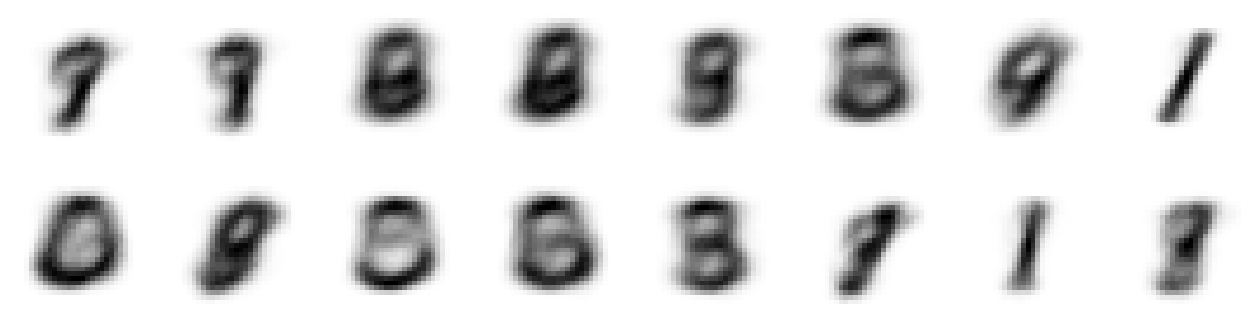

In [ ]:
def plot_samples(samples, samples_per_row=8):
    n_rows = len(samples) // samples_per_row
    n_tot = int(n_rows*samples_per_row)
    samples = samples[:n_tot]
    fig = plt.figure(figsize=(2*samples_per_row, 2*n_rows))
    for i, out in enumerate(samples):
        a = fig.add_subplot(n_rows, samples_per_row, i+1)
        plt.imshow(out, cmap='binary')
        a.axis("off")

    plt.show()

def get_n_params(model):
    return np.sum([np.prod(param.shape) for param in model.parameters()])


input_shape = (1, 28, 28)
latent_dim = 64

architecture = 'linear'

# load model
model = VAE(input_shape, latent_dim, architecture=architecture)
loaded_state_dict = torch.load(f"saved_models/vae_{architecture}.pt", map_location=torch.device('cpu'))
model.load_state_dict(loaded_state_dict)
model.eval()

print(f"Total number of parameters for {architecture} architecture: {get_n_params(model):d}")

x_hat = model.sample(n=16).detach().numpy().reshape(-1, 28, 28)

plot_samples(x_hat, samples_per_row=8)

# Train (Convolutional)

In [ ]:
def loss_fn(x, x_hat, logvar):
    # Reconstruction loss (could use also MSE, but BCE is good for inputs bounded in [0, 1])
    bce = F.binary_cross_entropy(x_hat, x, reduction='mean')

    # KLD between Gaussian rvs
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + kld


# define hyper parameters
batch_size = 128
epochs = 5  # 20
lr = 1e-3

architecture = 'conv'

torch.manual_seed(42)

input_shape = (1, 28, 28)
latent_dim = 64

# load model

model = VAE(input_shape, latent_dim, architecture=architecture)
model.to(device)

# define optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)

losses = []
best_loss = 100

if not os.path.isdir('saved_models'):
    os.makedirs('saved_models')

for epoch in range(epochs):

    train_loss = 0
    for x, _ in tqdm(train_loader):

        optimizer.zero_grad()

        x = x.to(device)
        x_hat, mu, logvar, z = model(x)

        loss = loss_fn(x, x_hat, logvar)
        train_loss += loss.item()
        loss.backward()


        optimizer.step()

    train_loss /= len(train_loader)
    print(f"Average loss per batch at epoch {epoch+1:03d}: {train_loss:.4f}")
    losses.append(train_loss)

    # save model if it improved
    if train_loss < best_loss:
        best_loss = train_loss
        torch.save(model.state_dict(), f'saved_models/vae_{architecture}.pt')

100%|██████████| 469/469 [00:23<00:00, 20.31it/s]


Average loss per batch at epoch 001: 0.2688


100%|██████████| 469/469 [00:24<00:00, 18.95it/s]


Average loss per batch at epoch 002: 0.2603


100%|██████████| 469/469 [00:28<00:00, 16.55it/s]


Average loss per batch at epoch 003: 0.2565


100%|██████████| 469/469 [00:27<00:00, 17.13it/s]


Average loss per batch at epoch 004: 0.2533


100%|██████████| 469/469 [00:26<00:00, 17.80it/s]

Average loss per batch at epoch 005: 0.2518


# Generate (Convolutional)

<ipython-input-12-1e091d8254e9>:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_state_dict = torch.load(f"saved_models/vae_{architecture}.pt", map_location=torch.de

Total number of parameters for linear architecture: 1116560


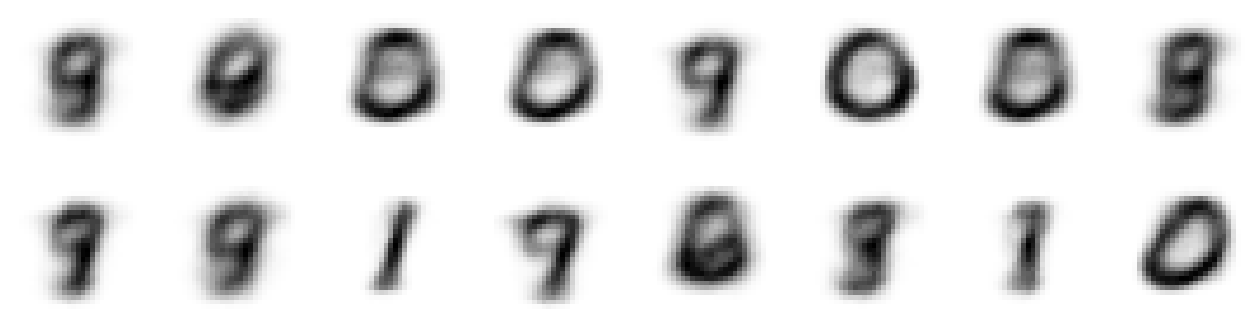

In [ ]:
def plot_samples(samples, samples_per_row=8):
    n_rows = len(samples) // samples_per_row
    n_tot = int(n_rows*samples_per_row)
    samples = samples[:n_tot]
    fig = plt.figure(figsize=(2*samples_per_row, 2*n_rows))
    for i, out in enumerate(samples):
        a = fig.add_subplot(n_rows, samples_per_row, i+1)
        plt.imshow(out, cmap='binary')
        a.axis("off")

    plt.show()

def get_n_params(model):
    return np.sum([np.prod(param.shape) for param in model.parameters()])


input_shape = (1, 28, 28)
latent_dim = 64

architecture = 'conv'

# load model
model = VAE(input_shape, latent_dim, architecture=architecture)
loaded_state_dict = torch.load(f"saved_models/vae_{architecture}.pt", map_location=torch.device('cpu'))
model.load_state_dict(loaded_state_dict)
model.eval()

print(f"Total number of parameters for {architecture} architecture: {get_n_params(model):d}")

x_hat = model.sample(n=16).detach().numpy().reshape(-1, 28, 28)

plot_samples(x_hat, samples_per_row=8)